# Did Retail-Plus members order less often in Q2, in plain Python, SQL and pandas, and which tool would you sign?

**How to read this copy.** Each placeholder holds its key, so the notebook runs clean from a fresh kernel, and the paragraph under each step says why each other letter fails. Sit the case first.

> **The client asks.** "You did the tree in plain Python in Week 1, in SQL on Monday. Do it a
> third way now, and tell me honestly which tool you would pick for which job, and which one you
> would refuse for Finance's numbers."
>
> Kavya Nair, senior analyst, Kalpa Retail data team

The question all three tools answer is the branch of Week 1's revenue tree that moved:
**Retail-Plus orders per member, Q1 against Q2**, where Q1 is April to June 2026 and Q2 is July
to September. Retail-Plus is Kalpa Retail's paid membership tier, and a member counts in a
quarter if they ordered in it. Orders per member is a quarter's orders divided by the members
who ordered in that quarter, the retail dossier's frequency. Finance, under Anand Iyer, reruns
its own numbers every Monday from the warehouse, Kalpa's Postgres database.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd
ENG = kit.engine()
print("connected to", kit.WAREHOUSE["dbname"])

connected to kalpa


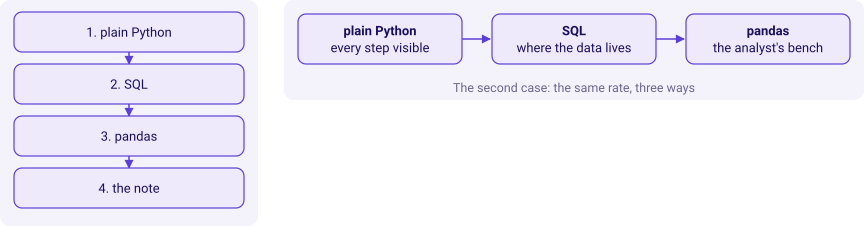

In [2]:
kit.side_by_side(
    kit.ladder(["plain Python", "SQL", "pandas", "the note"], show=False),
    kit.flow(["plain Python\nevery step visible", "SQL\nwhere the data lives",
              "pandas\nthe analyst's bench"], title="The second case: the same rate, three ways", show=False),
)

## Step 1. What does plain Python count, one row at a time?

The rows arrive as a list of dictionaries, the shape of Week 1's orders: one per Retail-Plus
order, with its customer and its quarter.

In [3]:
rows = kit.sql('''SELECT o.order_id, o.customer_id, o.quarter FROM orders o
                  JOIN customers c ON c.customer_id = o.customer_id
                  WHERE c.segment = 'Retail-Plus' ''')
orders_n = {"Q1": 0, "Q2": 0}
ids = {"Q1": [], "Q2": []}
for r in rows:
    orders_n[r["quarter"]] += 1
    ids[r["quarter"]].append(r["customer_id"])

# TODO 1. How many members ordered in each quarter?
#   a) {qq: len(ids[qq]) for qq in ids}
#   b) {qq: len(set(ids[qq])) for qq in ids}
#   c) {qq: len(set(ids["Q1"]) | set(ids["Q2"])) for qq in ids}
#   d) {qq: len(set(ids["Q1"]) & set(ids["Q2"])) for qq in ids}
members_n = {qq: len(set(ids[qq])) for qq in ids}
py = {qq: orders_n[qq] / members_n[qq] for qq in ("Q1", "Q2")}
print("plain Python:", {qq: round(v, 3) for qq, v in py.items()})

plain Python: {'Q1': 2.363, 'Q2': 1.842}


**Key 1b.** 1a counts every order as a member, so orders per member reads 1.000 in both quarters: rows counted as customers, Week 1 Monday's trap. 1c divides both quarters by the 107 members who ordered in either quarter, and 1d by the 60 who ordered in both, so each rate stands on members who did not order in that quarter; SQL, which counts each quarter's members on their own, disagrees with both in the next step.

In [4]:
kit.check("plain Python counts every Retail-Plus order", sum(orders_n.values()) == len(rows))
kit.check("each quarter's members are fewer than its orders", all(members_n[qq] < orders_n[qq] for qq in orders_n))
kit.table(["quarter", "orders", "members", "orders per member"],
          [(qq, orders_n[qq], members_n[qq], f"{py[qq]:.3f}") for qq in ("Q1", "Q2")], caption="Plain Python")

quarter,orders,members,orders per member
Q1,215,91,2.363
Q2,140,76,1.842


## Step 2. Does SQL, where the data lives, give the same number?

If SQL disagrees with plain Python, the cause can sit in marker 1 as well as in markers 2 and 3:
each side has to count the same members.

In [5]:
# TODO 2. Which expression gives orders per member, to three places?
#   a) orders / members
#   b) orders::numeric / members
#   c) members::numeric / orders
#   d) orders::numeric / (SELECT count(*) FROM customers)
# TODO 3. Which line keeps only Retail-Plus?
#   a) WHERE c.segment = 'Retail-Plus'
#   b) WHERE c.segment = 'Retail Plus'
#   c) WHERE c.segment LIKE 'Retail%'
#   d) WHERE c.segment <> 'Business'
SQL = '''WITH q AS (SELECT o.quarter, count(*) AS orders, count(DISTINCT o.customer_id) AS members
                    FROM orders o JOIN customers c ON c.customer_id = o.customer_id
                    WHERE c.segment = 'Retail-Plus'
                    GROUP BY o.quarter)
         SELECT quarter, orders, members, round(orders::numeric / members, 3) AS per_member
         FROM q ORDER BY quarter'''
sql_rows = kit.sql(SQL)
sq = {r["quarter"]: float(r["per_member"]) for r in sql_rows}
print("SQL:", sq)

SQL: {'Q1': 2.363, 'Q2': 1.842}


**Keys 2b and 3a.** 2a is Monday's trap: Postgres divides two whole numbers and returns 2 and 1. 2c turns the rate upside down. 2d divides by all 340 customers on the list, every segment, whoever ordered. 3b spells the segment with a space where the warehouse stores a hyphen, so no row matches and SQL returns no quarters at all; 3c keeps Retail-Core as well, since `LIKE 'Retail%'` matches both consumer tiers; 3d keeps Retail-Core and the Students.

In [6]:
kit.check("SQL returns one row per quarter", [r["quarter"] for r in sql_rows] == ["Q1", "Q2"])
kit.check("SQL agrees with plain Python to three places", all(abs(sq[qq] - py[qq]) < 0.001 for qq in sq), sq)

## Step 3. Does pandas, the analyst's bench, give the same number?

In [7]:
df = pd.read_sql('''SELECT o.order_id, o.customer_id, o.quarter, c.segment FROM orders o
                    JOIN customers c ON c.customer_id = o.customer_id''', ENG)
rp = df[df["segment"] == "Retail-Plus"]
orders_pd = rp.groupby("quarter")["order_id"].count()
# TODO 4. Which expression gives each quarter's members?
#   a) rp.groupby("quarter")["customer_id"].count()
#   b) rp.groupby("quarter").size()
#   c) rp.drop_duplicates("customer_id").groupby("quarter").size()
#   d) rp.groupby("quarter")["customer_id"].nunique()
members_pd = rp.groupby("quarter")["customer_id"].nunique()
pn = (orders_pd / members_pd).to_dict()
print("pandas:", {qq: round(v, 3) for qq, v in pn.items()})

pandas: {'Q1': 2.363, 'Q2': 1.842}


**Key 4d.** 4a and 4b count rows, which are orders, so the rate reads 1.000. 4c keeps one row per member before grouping, so a member who ordered in both quarters counts in only one of them: the two quarters' members add up to the 107 who ordered at all, and each rate stands on too few members.

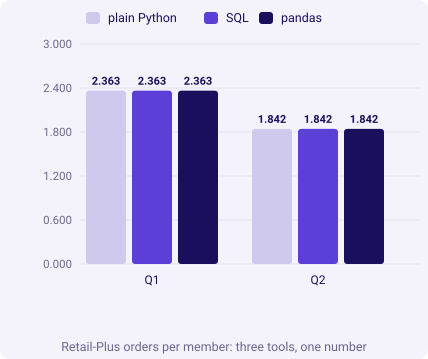

In [8]:
kit.check("pandas agrees with plain Python", all(abs(pn[qq] - py[qq]) < 1e-9 for qq in ("Q1", "Q2")))
kit.check("pandas agrees with SQL to three places", all(abs(pn[qq] - sq[qq]) < 0.001 for qq in ("Q1", "Q2")))
kit.columns(["Q1", "Q2"], [("plain Python", [round(py[qq], 3) for qq in ("Q1", "Q2")]),
                           ("SQL", [sq[qq] for qq in ("Q1", "Q2")]),
                           ("pandas", [round(pn[qq], 3) for qq in ("Q1", "Q2")])],
            fmt=lambda v: f"{v:.3f}", title="Retail-Plus orders per member: three tools, one number")

## Step 4. Which tool would you sign for each job, and which size tells the three apart?

The three agree, so the choice is about who has to trust, rerun or audit the number, and about
what each route cost to reach it.

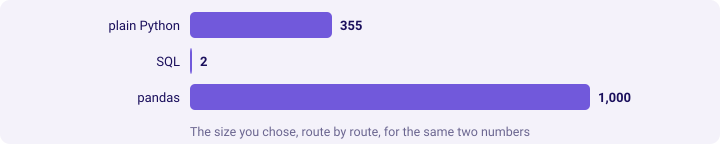

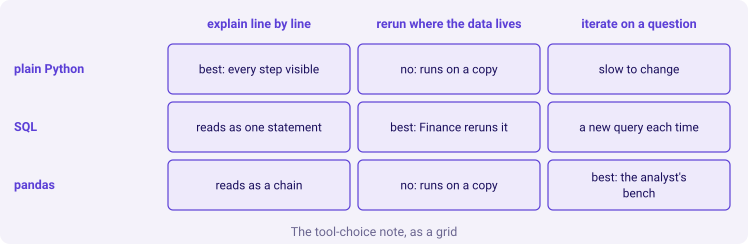

In [9]:
# TODO 5. Which size tells the three routes apart, listed as plain Python, SQL, pandas?
#   a) [len(py), len(sq), len(pn)]                      the rows in each answer
#   b) [sum(orders_n.values()), sum(r["orders"] for r in sql_rows), int(orders_pd.sum())]
#                                                       the orders each route counted
#   c) [len(rows), len(sql_rows), len(rp)]              the rows each route held after keeping Retail-Plus
#   d) [len(rows), len(sql_rows), len(df)]              the rows each route fetched from the warehouse
size = dict(zip(["plain Python", "SQL", "pandas"], [len(rows), len(sql_rows), len(df)]))
kit.bars(list(size.items()), title="The size you chose, route by route, for the same two numbers")

# TODO 6. Which route should own a number Finance reruns every Monday?
#   a) "pandas"            the growth team's table already holds the numbers
#   b) "plain Python"      an auditor can read every line
#   c) "SQL"               it runs where the data lives
#   d) "a CSV export"      Finance opens every number in a spreadsheet
finance_home = "SQL"
kit.matrix(["plain Python", "SQL", "pandas"], ["explain line by line", "rerun where the data lives", "iterate on a question"],
           [["best: every step visible", "no: runs on a copy", "slow to change"],
            ["reads as one statement", "best: Finance reruns it", "a new query each time"],
            ["reads as a chain", "no: runs on a copy", "best: the analyst's bench"]],
           title="The tool-choice note, as a grid")

**Keys 5d and 6c.** 5d counts the rows each route fetched from the warehouse: plain Python 355, SQL 2 and pandas 1,000. The pandas gap comes from how its route was written: it read every order and kept Retail-Plus in memory, and a `read_sql` with the `WHERE` in it would have fetched 355, like plain Python. 5a gives 2, 2 and 2, the answers themselves, which tie; 5b gives 355 three times, the orders every route counted; 5c gives 355, 2 and 355, the rows pandas kept after its filter, which hides the 645 other orders it fetched. Finance's number lives where Finance can rerun and audit it, in the warehouse, as a query that sends only its answer (6c), and the check ties that choice to the size you chose. pandas (6a) and a plain loop (6b) run on a copy on one machine, and the loop is for a question explained once, line by line; an export (6d) is a copy that ages from the moment it is written.

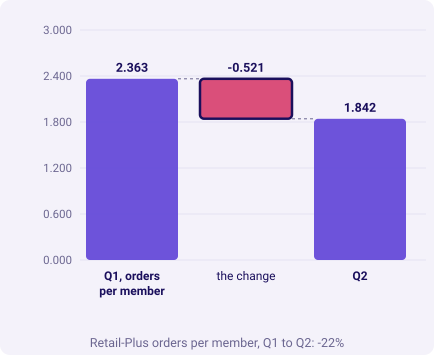

In [10]:
kit.check("the three tools agree on both quarters",
          all(abs(py[qq] - pn[qq]) < 1e-9 and abs(py[qq] - sq[qq]) < 0.001 for qq in ("Q1", "Q2")))
kit.check("the size you chose tells the three routes apart", len(set(size.values())) == 3)
kit.check("the home you chose for Finance's number is the route your size ranks first",
          finance_home == min(size, key=size.get))
fall = pn["Q2"] / pn["Q1"] - 1
kit.bridge(("Q1, orders per member", round(pn["Q1"], 3)), [("the change", round(pn["Q2"] - pn["Q1"], 3))],
           end_label="Q2", fmt=lambda v: f"{v:.3f}", lit=(0,),
           title=f"Retail-Plus orders per member, Q1 to Q2: {fall:+.0%}")
kit.check_summary()

**Post:** your six letters, and your tool-choice note in the brief's format: one line per tool
with the job it owns and the rows it fetched, and the tool you would refuse for Finance's
numbers, with the reason.